In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import itertools as itr
import numpy as np
from sklearn.metrics import mean_squared_error
from random import randrange
from tabulate import tabulate

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.func import functional_call, vmap, vjp, jvp, grad

from scipy.linalg import svdvals, norm
from scipy.special import softmax
from scipy.optimize import minimize_scalar

from common.const import DATASET_PATH
from common.util import *
from common.ffn_model.minst.ffn_minst_util import MetaData
from common.ffn_model.minst.ffn_minst_optimise import \
    StepCalculatorZhangLambda, StepCalculatorEtaSoftmaxArmihoNorm2, StepCalculatorEtaSoftmaxArmihoNorm1\
        , StepCalculatorZhangSimplified, reduce_to_active
from common.ffn_model.minst.ffn_minst_relu import MNISTReLU

from torchvision.datasets import CIFAR10
from torchvision import transforms
#from torchvision.utils import make_grid

import logging

In [2]:
logging.basicConfig(filename="log_convcrity_cifar10_epochsd.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s",
                datefmt="%m/%d/%Y %I:%M:%S")


#### CIFAR10 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 10 #26  # num of classes

INPUT_WIDTH, HIDDEN_WIDTH = 4096, 512 #1000, 400 #2000, 800 #1024, 128 #1000, 400 #500, 200 #1000, 400 #500, 200 #250, 100

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0)

DEVICE = torch.device('cpu')  # change to `cuda:0` when available


##### UTILS

In [6]:
HISTORY_NORM1 = collections.defaultdict(list)
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_ZHS = collections.defaultdict(list)
HISTORY_ZHL = collections.defaultdict(list)
HISTORY_OPTADA = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)

#### Compare optimisers

In [7]:
def print_comparison():
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    axes[0].plot(HISTORY_NORM1['test_loss'], color='g', alpha=.5, label='Test norm1')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Test norm2')
    axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    axes[1].plot(HISTORY_NORM1['test_accuracy'], color='g', alpha=.5, label='Test norm1')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Test norm2')
    axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same FFN-structure for different optimisers")

    plt.show()

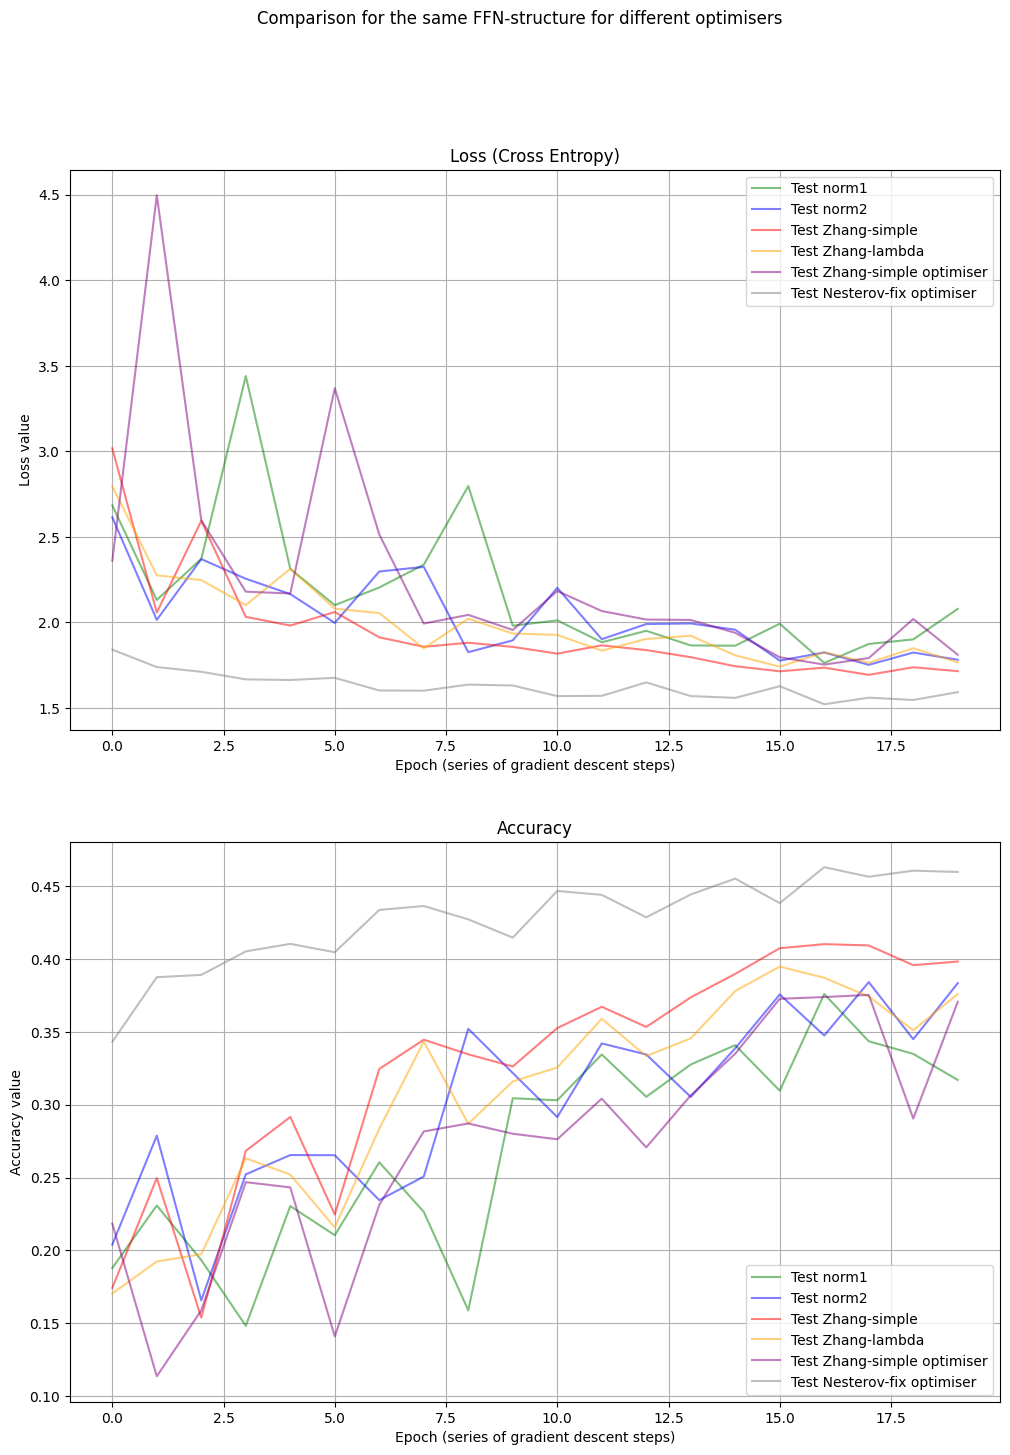

In [8]:
def test_loop(testNet, test_loss_meter, test_accuracy_meter):
    for test_batch in test_dataloader:
        images_raw, labels = test_batch
        #labels = labels_raw - 1
        images = 0.299*images_raw[:,0,:,:]+0.587*images_raw[:,1,:,:]+0.114*images_raw[:,2,:,:]
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            batch_size = images.shape[0]
            xx = images.view(batch_size, -1)
            logits = testNet.forward_(xx)

            zz_logits = np.transpose(logits.detach().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

NUM_EPOCH = 20

#results = []
#head = ["type", "loss", "accuracy"]

meta = MetaData(input_dim = INPUT_DIM, input_width = INPUT_WIDTH, hidden_width = HIDDEN_WIDTH, output_dim = OUTPUT_DIM\
                , batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0)

stepCalcZhL = StepCalculatorZhangLambda(meta)
stepCalcZhS = StepCalculatorZhangSimplified(meta)
stepCalcSoftmax2 = StepCalculatorEtaSoftmaxArmihoNorm2(meta)
stepCalcSoftmax1 = StepCalculatorEtaSoftmaxArmihoNorm1(meta)

testZhl = MNISTReLU(meta)
testZhl.set_log_level("info")
testZhl.set_slopes(slope_plus, slope_minus)
testZhl.init_weights(cb, cw)
testZhl.to(DEVICE)
testZhl.save_txt("tmp")

testZhS = MNISTReLU(meta)
testZhS.set_slopes(slope_plus, slope_minus)
testZhS.init_weights_txt('tmp')
testZhS.to(DEVICE)

testNorm1 = MNISTReLU(meta)
testNorm1.set_slopes(slope_plus, slope_minus)
testNorm1.init_weights_txt('tmp')
testNorm1.to(DEVICE)

testNorm2 = MNISTReLU(meta)
testNorm2.set_slopes(slope_plus, slope_minus)
testNorm2.init_weights_txt('tmp')
testNorm2.to(DEVICE)

testOptada = MNISTReLU(meta)
testOptada.set_slopes(slope_plus, slope_minus)
testOptada.init_weights_txt('tmp')
testOptada.to(DEVICE)
loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = optim.SGD(testOptada.parameters(), lr=1e-2)

testOptfix = MNISTReLU(meta)
testOptfix.set_slopes(slope_plus, slope_minus)
testOptfix.init_weights_txt('tmp')
testOptfix.to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss() #(reduction='sum')
optimizerFix = optim.SGD(testOptfix.parameters(), lr=1e-2, momentum=0.9, nesterov=True)

# ZhL
for epoch in range(NUM_EPOCH):
    for train_batch in train_dataloader:
        images_raw, labels = train_batch
        #labels = torch.tensor([x-1 for x in labels_raw])
        images = 0.299*images_raw[:,0,:,:]+0.587*images_raw[:,1,:,:]+0.114*images_raw[:,2,:,:]
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        batch_size = images.shape[0]
        xx = images.view(batch_size, -1)

        logging.info("##Step with Zh-lambda")
        with torch.no_grad():
            logitsZhl = testZhl.forward_(xx)
        etaZhl, _ = stepCalcZhL.step(testZhl, logitsZhl.detach().numpy(), labels, xx)

        logging.info("##Step with Zh-simplified")
        with torch.no_grad():
            logitsZhS = testZhS.forward_(xx)
        etaZhS, _ = stepCalcZhS.step(testZhS, logitsZhS.detach().numpy(), labels, xx)

        logging.info("##Step with norm2-optim")
        with torch.no_grad():
            logits2 = testNorm2.forward_(xx)
        eta2, _ = stepCalcSoftmax2.step(testNorm2, logits2.detach().numpy(), labels, xx)

        logging.info("##Step with norm1-optim")
        with torch.no_grad():
            logits1 = testNorm1.forward_(xx)
        eta1, _ = stepCalcSoftmax1.step(testNorm1, logits1.detach().numpy(), labels, xx)

        logging.info("##Step with Optim-adaptive ZhS")
        optimizer.zero_grad()
        logitsOptada = testOptada.forward_(xx)
        lossOptada = loss_fn(logitsOptada, labels)
        lossOptada.backward()
        etaOptada = stepCalcZhS.calc_eta(testOptada, lossOptada.item())
        optimizer.param_groups[0]['lr'] = etaOptada
        optimizer.step()

        logging.info("##Step with Optim-fix")
        logitsOptfix = testOptfix.forward_(xx)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

    # testing loop
    test_loss1_meter, test_accuracy1_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm1, test_loss1_meter, test_accuracy1_meter)
    HISTORY_NORM1['test_loss'].append(test_loss1_meter.avg)
    HISTORY_NORM1['test_accuracy'].append(test_accuracy1_meter.avg)

    test_loss2_meter, test_accuracy2_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm2, test_loss2_meter, test_accuracy2_meter)
    HISTORY_NORM2['test_loss'].append(test_loss2_meter.avg)
    HISTORY_NORM2['test_accuracy'].append(test_accuracy2_meter.avg)

    test_lossZhs_meter, test_accuracyZhs_meter = AverageMeter(), AverageMeter(),
    test_loop(testZhS, test_lossZhs_meter, test_accuracyZhs_meter)
    HISTORY_ZHS['test_loss'].append(test_lossZhs_meter.avg)
    HISTORY_ZHS['test_accuracy'].append(test_accuracyZhs_meter.avg)

    test_lossZhl_meter, test_accuracyZhl_meter = AverageMeter(), AverageMeter(),
    test_loop(testZhl, test_lossZhl_meter, test_accuracyZhl_meter)
    HISTORY_ZHL['test_loss'].append(test_lossZhl_meter.avg)
    HISTORY_ZHL['test_accuracy'].append(test_accuracyZhl_meter.avg)

    test_lossOptada_meter, test_accuracyOptada_meter = AverageMeter(), AverageMeter(),
    test_loop(testOptada, test_lossOptada_meter, test_accuracyOptada_meter)
    HISTORY_OPTADA['test_loss'].append(test_lossOptada_meter.avg)
    HISTORY_OPTADA['test_accuracy'].append(test_accuracyOptada_meter.avg)

    test_lossOptfix_meter, test_accuracyOptfix_meter = AverageMeter(), AverageMeter(),
    test_loop(testOptfix, test_lossOptfix_meter, test_accuracyOptfix_meter)
    HISTORY_OPTFIX['test_loss'].append(test_lossOptfix_meter.avg)
    HISTORY_OPTFIX['test_accuracy'].append(test_accuracyOptfix_meter.avg)    
    
    print_comparison()
